### Libraries

In [1]:
pip install numpy matplotlib pymc arviz

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

### A MCMC example

NUTS[numpyro]: [mass_growth, initial_density, density_decrease_param]


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


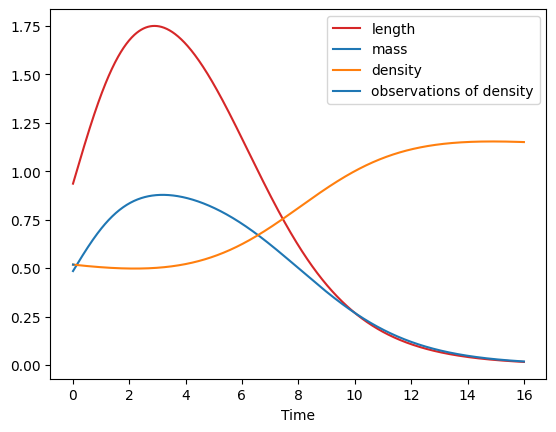

In [3]:
# # create some data
def sigmoid(x, a=1.0, A=1.0):
    return A/(1 + np.exp(-a * x))
# MAX_MASS = 0.6
# MAX_LENGTH = 1.0
# GROWTH_RATE_LENGTH = 1.0
# GROWTH_RATE_MASS = 0.8
# DELAY_MELT = 10
# INITIAL_DENSITY = 1.0
# DENSITY_COUPLING = 0.5
# DENSITY_A = 1.0
# def mass_expr(t, growth_rate, maximum, delay): 
#     return sigmoid(t, a=growth_rate, A=maximum) - sigmoid(t-delay, a=growth_rate, A=maximum)


# def density_expr(t, initial, coupling, delay, a): 
#     return (initial - coupling) + coupling * np.exp(-t) #+ sigmoid(t-delay, a=a, A=coupling)

# mass = mass_expr(time, GROWTH_RATE_MASS, MAX_MASS, DELAY_MELT)
# # density = density_expr(time, INITIAL_DENSITY, DENSITY_COUPLING, DELAY_MELT, DENSITY_A)   
# density = np.ones(n_data)


n_data = 1000
MASS_GROWTH_RATE = 1.0
MELT_RATE = 0.5
INITIAL_DENSITY = 1.0
DENSITY_DECREASE_PARAM = 0.1

time = np.linspace(0.01, 16, n_data)
MELT_TIME = time.max()/2

def mass_eq(t, growth_rate, melt_time):
    return sigmoid(time, a=growth_rate) - sigmoid(time-melt_time, a=MELT_RATE)

def density_eq(t, initial, decrease, melt_time):
    return initial - sigmoid(time, a=decrease) + sigmoid(time-melt_time, a=MELT_RATE)

mass = mass_eq(time, MASS_GROWTH_RATE, MELT_TIME)
# density = INITIAL_DENSITY + INITIAL_DENSITY * np.exp(-DENSITY_DECREASE_PARAM*time)
density = density_eq(time, INITIAL_DENSITY, DENSITY_DECREASE_PARAM, MELT_TIME)
length = mass/density

# discretize the length into counts
length_counts = length * 10

known_density = density[:2]
known_density_time = time[:2] 

# mass = sigmoid(time, a=GROWTH_RATE_MASS, A=MAX_MASS) - sigmoid(time-DELAY_MELT, a=GROWTH_RATE_MASS, A=MAX_MASS)


# assume we know the density when the mass melts
# known_densities = density[np.where(time>3/2 * DELAY_MELT)]
# known_density_times = time[np.where(time>3/2 * DELAY_MELT)]

fig, ax=plt.subplots()

ax.plot(time, length, label="length", c="tab:red")
ax.plot(time, mass, label="mass", c="tab:blue")
ax.plot(time, density, label="density", c="tab:orange")
ax.plot(known_density_time, known_density, label="observations of density")
# ax.plot(time, length_counts, label="counts")
ax.set_xlabel("Time")
ax.legend()

def my_model():
    with pm.Model() as model:

        # define parameters determining the growth rate of parameters
        # mass_growth = pm.HalfNormal("mass_growth", sigma=0.5)
        # mass_max = pm.HalfNormal("mass_max", sigma=1.0)
        # # density_a = pm.HalfNormal("density_a", sigma=0.5)
        # density_a = pm.Normal("density_a", mu=0.5, sigma=0.01)
        # initial_density = pm.HalfNormal("initial_density", sigma=5.0)
        # density_coupling = pm.Normal("density_coupling", mu=0.5, sigma=0.2)
        # # delay_melt = pm.Normal("delay_melt", mu=10.0, sigma=0.5)
        # delay_melt = DELAY_MELT

        mass_growth = pm.Normal("mass_growth", mu=1.0, sigma=5.0)
        initial_density = pm.HalfNormal("initial_density", sigma=5.0)
        density_decrease_param = pm.HalfNormal("density_decrease_param", sigma=5.0)

        # latent_mass = pm.Deterministic("latent_mass", mass_growth * time)
        latent_mass = pm.Deterministic("latent_mass", mass_eq(time, mass_growth, MELT_TIME))
        # latent_density = pm.Deterministic("latent_density", initial_density + initial_density * pm.math.exp(-density_decrease_param*time))
        latent_density = pm.Deterministic("latent_density", density_eq(time, initial_density, density_decrease_param, MELT_TIME))
        # define how mass and density evolves over time
        # latent_mass = pm.Deterministic("latent_mass", mass_expr(time, mass_growth, mass_max, delay_melt))
        
        # latent_density = pm.Deterministic("latent_density", density_expr(time, initial_density, density_coupling, delay_melt, density_a)) 
        # latent_density = pm.Deterministic("latent_density", initial_density + density_a * time)
        # latent_density = pm.Deterministic("latent_density", pm.math.ones(n_data))
        # define a predictor for the observed length
       
        predicted_length = pm.Deterministic("predicted_length", latent_mass/latent_density)
        y = pm.Normal("y", mu=predicted_length, sigma=0.5, observed=length)
        # in this case we imagine that we know how to translate the length into counts
        # predicted_counts = pm.Deterministic("predicted_counts", predicted_length * 10)
        # y = pm.Poisson("y", observed=length_counts, mu=predicted_counts[: len(time)])

        # # utilize that we have "observations of density"
        density_at_known_times = pm.Normal(
            "density_at_known_times",
            # mu = density_expr(known_density_times, initial_density, density_coupling, delay_melt, density_a),
            # mu = initial_density + density_a * known_density_times,
            mu=initial_density + pm.math.exp(- density_decrease_param*known_density_time),
            sigma = 0.1, # <- far away from negative densities
            observed=known_density)

        idata = pm.sample(
            draws=1000,
            tune=1000,
            nuts_sampler="numpyro")

    return idata, model
idata, model = my_model()



idata.posterior["latent_density"].shape = (4, 1000, 1000)


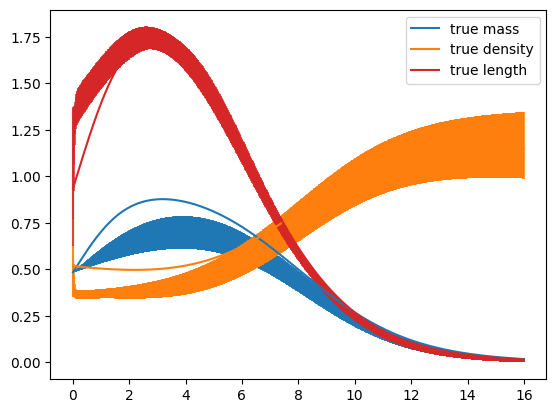

In [4]:
print(f"{idata.posterior["latent_density"].shape = }")
def credible_interval(posterior):
    lower = np.percentile(posterior, 2.5, axis=0)
    upper = np.percentile(posterior, 97.5, axis=0)
    median = np.percentile(posterior, 50.0, axis=0)
    return (lower, upper), median

density_posterior = np.array(idata.posterior["latent_density"]).reshape((-1, n_data))
mass_posterior = np.array(idata.posterior["latent_mass"]).reshape((-1, n_data))
length_posterior = np.array(idata.posterior["predicted_length"]).reshape((-1, n_data))

(density_lower, density_upper), density_median = credible_interval(density_posterior)
(mass_lower, mass_upper), mass_median = credible_interval(mass_posterior)
(length_lower, length_upper), length_median = credible_interval(length_posterior)
fig, ax=plt.subplots()
ax.vlines(time, mass_lower, mass_upper, color="tab:blue", alpha=0.75)
ax.vlines(time, density_lower, density_upper, color="tab:orange", alpha=0.75)
ax.vlines(time, length_lower, length_upper, color="tab:red", alpha=0.75)
# ax.scatter(time, mass_median, label="estimated mass", c="tab:blue")
# ax.scatter(time, density_median, label="estimated density", c="tab:orange")
# ax.scatter(time, length_median, label="estimated length", c="tab:red")

ax.plot(time, mass, label="true mass", c="tab:blue")
ax.plot(time, density, label="true density", c="tab:orange")
ax.plot(time, length, label="true length", c="tab:red")


ax.legend()


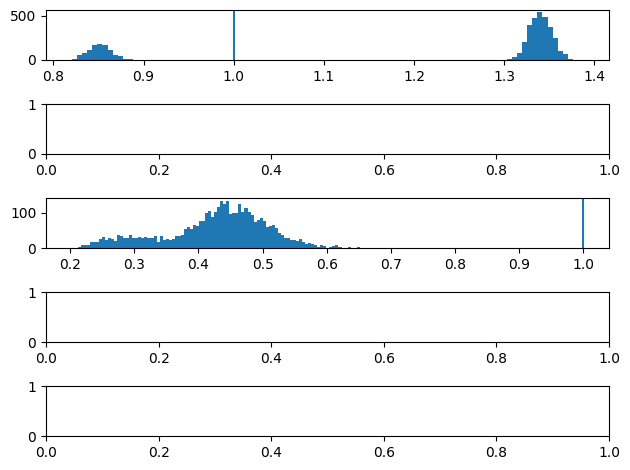

In [5]:
fig, axs=plt.subplots(5, 1)

id = np.array(idata.posterior["initial_density"]).reshape(-1)
# dc = np.array(idata.posterior["density_coupling"]).reshape(-1)
mg = np.array(idata.posterior["mass_growth"]).reshape(-1)
# mm = np.array(idata.posterior["mass_max"]).reshape(-1)
# dm = np.array(idata.posterior["delay_melt"]).reshape(-1)
axs[0].hist(id, bins=100)
axs[0].axvline(INITIAL_DENSITY)
# axs[1].hist(dc, bins=100)
# axs[1].axvline(DENSITY_COUPLING)
axs[2].hist(mg, bins=100)
axs[2].axvline(MASS_GROWTH_RATE)
# axs[3].hist(mm, bins=100)
# axs[3].axvline(MAX_MASS)
# axs[4].hist(dm, bins=100)
# axs[4].axvline(DELAY_MELT)

fig.tight_layout()